In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd / "FLP-NAR", Path("/FLP-NAR")]
repo_root = None
for c in candidates:
    if (c / "src").exists():
        repo_root = c
        break

if repo_root is None:
    raise RuntimeError("Could not find repository root containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

print(f"Using repo root: {repo_root}")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Using repo root: /home/simon/repos/FLP-NAR
Using device: cuda


In [3]:
from src.data.data import LossConfig, ramp_down
from src.models.reasoners import Reasoner
from src.training.training import Trainer, generate_training_validation_datasets
from src.evaluation.evaluation import create_test_datasets, run_inference
from src.utils.visualization import plot_inference_results_vs_optimum, plot_inference_results_vs_dual, plot_training_history, plot_size_scalability, plot_facility_count_prediction

/home/simon/repos/FLP-NAR/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
SEED = 33

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# Dataset configs (mirrors test.ipynb scales)
TRAIN_CONFIGS = [
    {"n_fac": 10, "n_cli": 5, "n_samples": 500},
    {"n_fac": 5, "n_cli": 10, "n_samples": 500},
    {"n_fac": 10, "n_cli": 10, "n_samples": 2000},
]

VAL_CONFIGS = [
    {"n_fac": 10, "n_cli": 10, "n_samples": 200},
    {"n_fac": 15, "n_cli": 15, "n_samples": 100},
    {"n_fac": 20, "n_cli": 20, "n_samples": 50},
    {"n_fac": 30, "n_cli": 30, "n_samples": 30},
    {"n_fac": 100, "n_cli": 100, "n_samples": 15},
]

BATCH_SIZE = 256
train_loaders, val_loaders_by_scale = generate_training_validation_datasets(
    train_configs=TRAIN_CONFIGS,
    val_configs=VAL_CONFIGS,
    batch_size=BATCH_SIZE,
)

print(f"train loaders: {len(train_loaders)}")
print(f"val scales: {list(val_loaders_by_scale.keys())}")

loading instances from cache
  10x5: 375 train / 125 val
loading instances from cache
  5x10: 375 train / 125 val
loading instances from cache
  10x10: 1500 train / 500 val
loading instances from cache
val scale 10x10: 200 samples
loading instances from cache
val scale 15x15: 100 samples
loading instances from cache
val scale 20x20: 50 samples
loading instances from cache
val scale 30x30: 30 samples
loading instances from cache
val scale 100x100: 15 samples
train loaders: 3
val scales: ['5x10', '10x5', '10x10', '15x15', '20x20', '30x30', '100x100']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Reasoner(hidden_dim=128, tf_prob=0.5).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

loss_config = LossConfig(
    weights={
        "alpha_loss": 0.5, "beta_loss": 0.5, "x_loss": 0.5,
        "y_loss": 0.5, "delta_loss": 1.0, "x_res_loss": 2.0,
        "y_res_loss": 2.0, "optimum_loss": 0.1, "optimum_diff": 0.0, "dual_diff": 0.0,
    },
    schedulers={
        "alpha_loss": ramp_down(150),
        "beta_loss": ramp_down(150),
        "x_loss": ramp_down(150),
        "y_loss": ramp_down(150),
        "delta_loss": ramp_down(150),
        #"optimum_loss": delayed_ramp(0, 50),
        "x_res_loss": ramp_down(150),
        "y_res_loss": ramp_down(150),
    },
    tf_end=150,
)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-7,
)

trainer = Trainer(
    model=model,
    optimizer=optimizer,
    loss_config=loss_config,
    lr_scheduler=lr_scheduler,
    device=device,
    checkpoint_dir="checkpoints",
)

trainer.model.processor.processor.mixing = False

print(f"device: {device}")
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

/home/simon/repos/FLP-NAR/src/models/processors.py:168: UserWarning: There exist node types ({'x'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.x_to_alpha = HeteroConv({
/home/simon/repos/FLP-NAR/src/models/processors.py:173: UserWarning: There exist node types ({'alpha', 'y'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.to_beta = HeteroConv({
/home/simon/repos/FLP-NAR/src/models/processors.py:185: UserWarning: There exist node types ({'beta', 'alpha'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.out = HeteroConv({


device: cuda
params: 660,494


In [ ]:
N_EPOCHS = 10
# history = trainer.fit(
#     train_loaders=train_loaders,
#     val_loaders=val_loaders_by_scale,
#     n_epochs=N_EPOCHS,
#     verbose=True,
# )

Training: 100%|██████████| 10/10 [02:15<00:00, 13.52s/it, lr=1.0e-04 t_loss=0.745 v_loss=0.914 t_opt=1.353 v_opt=1.511 t_dual=1.298 v_dual=1.442]


Best val loss: 0.9136


In [8]:
TEST_SIZES = {
    (5, 5): 20,
    (10, 10): 20,
    (15, 15): 20,
    (20, 20): 20,
    (10, 20): 20,
    (20, 10): 20,
    (30, 30): 20,
    (50, 50): 20,
    (100, 100): 20,
    (200, 200): 10,
}

# `type` can be: "metric", "weighted", "random"
type = "weighted"

if type == "weighted":
    TEST_SIZES.update({
        (300, 300): 5,
        (400, 400): 2,
        (500, 500): 2,
    })

exact = True
base_seed = 9999
test_datasets = {}

for setting in TEST_SIZES:
    test_datasets.update(create_test_datasets(
        sizes=[setting], 
        n_samples=TEST_SIZES[setting], 
        type=type, 
        exact=exact, 
        base_seed=base_seed)
    )

print(f"test sizes: {len(test_datasets)}")

loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
loading instances from cache
test sizes: 13


In [ ]:
trainer.load_checkpoint("checkpoints/pretrained_model.pt")

results_df = run_inference(
    datasets=test_datasets,
    trainer=trainer,
    repair=True,
)

results_df.head()

evaluating 5x5
evaluating 10x10
evaluating 15x15
evaluating 20x20
evaluating 10x20
evaluating 20x10
evaluating 30x30
evaluating 50x50
evaluating 100x100
evaluating 200x200
evaluating 300x300
evaluating 400x400
evaluating 500x500


,size,n_fac,n_cli,predicted,optimum,dual_bound,opt_ratio,dual_ratio,opt_gap_pct,n_fac_opened,n_fac_target,solution_time,exact_time,dual_time
0,5x5,5,5,1.803156,1.380088,1.380088,1.306551,1.306551,30.655146,2,1,0.348423,0.004631,0.000778
1,5x5,5,5,2.146629,1.881540,2.408530,1.140889,0.891261,14.088941,2,1,0.123192,0.004964,0.001903
2,5x5,5,5,2.239079,1.420713,1.420713,1.576025,1.576025,57.602489,4,1,0.118873,0.004677,0.000981
3,5x5,5,5,2.504456,1.807091,1.895447,1.385905,1.321301,38.590479,3,2,0.100841,0.004380,0.000791
4,5x5,5,5,2.763138,2.550788,2.942413,1.083249,0.939072,8.324885,2,1,0.127504,0.004140,0.000796


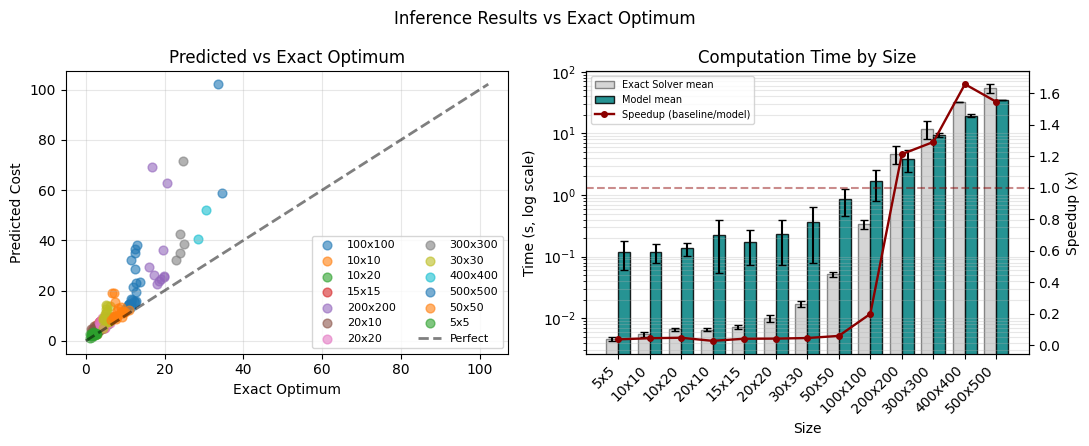

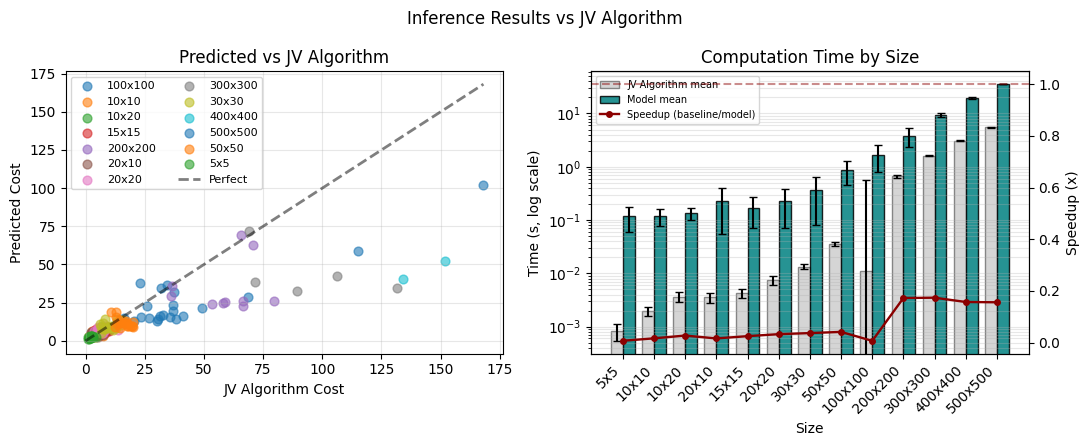

In [10]:
fig1 = plot_inference_results_vs_optimum(results_df)
plt.show()

fig2 = plot_inference_results_vs_dual(results_df)
plt.show()